In [1]:
from src.preprocessing.loading import load_df
from src.preprocessing.filtering import drop_all, quality_filter
from src.preprocessing.prepare import train_val_test_split, robust_normalize, speaker_normalize
from src.preprocessing.aggregating import aggregate

from src.visualization.plots import boxplot_scatter, label_distribution

In [2]:
df = load_df()
df = drop_all(df)
df = quality_filter(df)

df_train, df_val, df_test = train_val_test_split(df)
df_train, df_val, df_test = speaker_normalize(df_train, df_val, df_test)

print(df.head())

---------- Loading Data ----------
---------- Dropping unnecessary features ----------
---------- Start filtering ----------
Before filtering: 15780 frames
After filtering: 15430 frames
---------- Finished filtering ----------
   confidence  success  AU01_r  AU02_r  AU04_r  AU05_r  AU06_r  AU07_r  \
0        0.93        1    0.00     0.0    0.72     0.0    0.69     0.0   
1        0.98        1    0.03     0.0    0.50     0.0    0.70     0.0   
2        0.98        1    0.13     0.0    0.26     0.0    0.75     0.0   
3        0.93        1    0.43     0.0    0.00     0.0    0.84     0.0   
4        0.93        1    0.86     0.0    0.00     0.0    0.92     0.0   

   AU09_r  AU12_r  AU45_r  clip_id  label source_id  duration       split  
0    2.05     0.0    1.46  Art6_S1    1.0      Art6       4.0  validation  
1    1.89     0.0    1.75  Art6_S1    1.0      Art6       4.0  validation  
2    1.78     0.0    1.92  Art6_S1    1.0      Art6       4.0  validation  
3    1.72     0.0    2.1

In [3]:
df_train_agg = aggregate(df_train)
print(df_train_agg.head())

                  AU01_r    AU02_r    AU04_r    AU05_r    AU06_r    AU07_r  \
clip_id                                                                      
Phi3_S108       0.564263  1.051347  0.504960  1.465909  0.392447 -0.070782   
Phi3_S114       0.549499  1.293907  0.212078  1.379032  0.177181 -0.319571   
Phi3_S129       0.026987  0.439614  0.195135  1.423913 -0.278004  0.489130   
Phi3_S145_S146  0.653017  1.159722 -0.169271  1.000000  1.104064  0.529851   
Phi3_S171       0.207941  0.430976  0.282828  0.901515 -0.150470 -0.432610   

                  AU09_r    AU12_r    AU45_r  confidence  success  label  \
clip_id                                                                    
Phi3_S108       1.778620  0.002392  0.697861    0.976212        1    0.0   
Phi3_S114       0.611111  0.334890  0.740275    0.978387        1    1.0   
Phi3_S129       0.908213  0.397025  0.358696    0.974565        1    1.0   
Phi3_S145_S146  1.107639  1.868421  0.273897    0.980000        1    0.0 

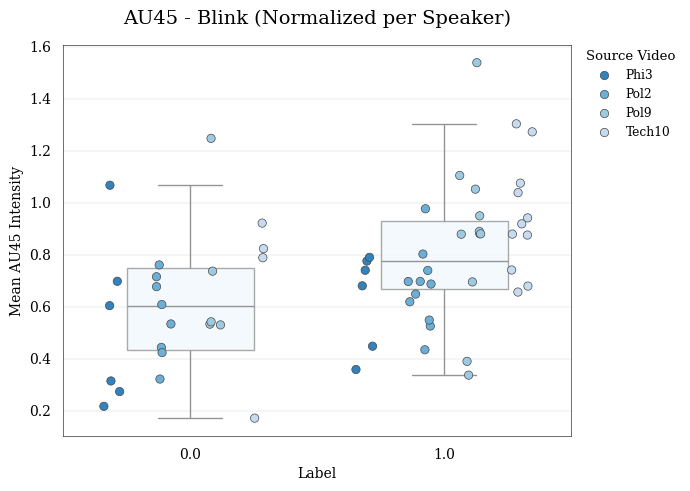

In [4]:
boxplot_scatter(df_train_agg, "AU45", "Blink (Normalized per Speaker)")

In [5]:
from matplotlib import colormaps

print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

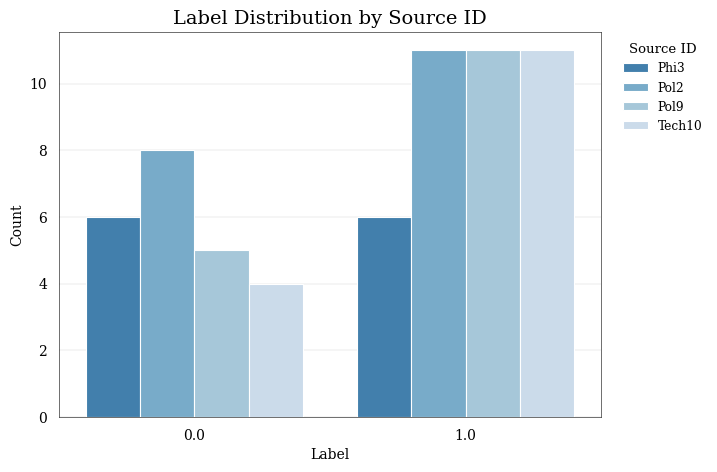

In [6]:
label_distribution(df_train_agg)